In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\kotig\OneDrive\Desktop\nivesh\sample_dirty_data.csv")

df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  215 non-null    int64  
 1   name         215 non-null    str    
 2   age          198 non-null    float64
 3   city         193 non-null    str    
 4   department   175 non-null    str    
 5   product      215 non-null    str    
 6   quantity     201 non-null    float64
 7   price        202 non-null    float64
 8   order_date   215 non-null    str    
 9   rating       195 non-null    float64
 10  email        204 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 18.6 KB


,customer_id,name,age,city,department,product,quantity,price,order_date,rating,email
count,215.000000,215,198.000000,193,175,215,201.000000,202.000000,215,195.000000,204
unique,NaN,135,NaN,34,7,10,NaN,NaN,142,NaN,159
top,NaN,Manish Verma,NaN,Kolkata,IT,Mobile,NaN,NaN,2024-08-15,NaN,ajay.pillai88@example.com
freq,NaN,5,NaN,24,31,30,NaN,NaN,5,NaN,3
mean,1082.362791,NaN,42.388889,NaN,NaN,NaN,5.552239,24664.300396,NaN,2.928205,NaN
std,48.278577,NaN,13.274351,NaN,NaN,NaN,2.745634,14231.531127,NaN,1.466103,NaN
min,1000.000000,NaN,18.000000,NaN,NaN,NaN,1.000000,774.470000,NaN,1.000000,NaN
25%,1041.500000,NaN,33.000000,NaN,NaN,NaN,3.000000,12756.720000,NaN,2.000000,NaN
50%,1084.000000,NaN,43.000000,NaN,NaN,NaN,6.000000,22824.005000,NaN,3.000000,NaN
75%,1121.500000,NaN,54.000000,NaN,NaN,NaN,8.000000,37608.877500,NaN,4.000000,NaN


# 1. Overview of the Dataset
This dataset contains 215 customer order records with 11 columns including 
demographics, product info, and pricing. Initial inspection revealed missing 
values and duplicate entries requiring cleanup.

In [4]:
df.isna().sum()                
df.duplicated().sum()           
df[df.duplicated()]            
df["city"].unique()            

<StringArray>
[   'JAIPUR',    'Mumbai',    'Jaipur',   'CHENNAI',   'kolkata', 'Bangalore',
   'Kolkata',     'delhi', 'Hyderabad',   'Chennai',    'mumbai',         nan,
    'jaipur', 'HYDERABAD',      'Pune', 'Ahmedabad', 'bangalore',   'KOLKATA',
     'Delhi', ' Chennai ',   'chennai',   'Lucknow', 'ahmedabad',  ' Jaipur ',
 ' Kolkata ',     'DELHI',    'MUMBAI', 'AHMEDABAD', ' Lucknow ',  ' Mumbai ',
      'pune',   ' Delhi ', 'hyderabad',    ' Pune ', 'BANGALORE']
Length: 35, dtype: str

In [5]:
df_clean = df.drop_duplicates()
print(f"Removed {len(df) - len(df_clean)} duplicate rows")

Removed 28 duplicate rows


In [6]:
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())

df_clean["department"] = df_clean["department"].fillna("Unknown")
df_clean["city"] = df_clean["city"].fillna("Unknown")

df_clean = df_clean.dropna(subset=["email"])

# 2. Data Cleaning Steps
- Removed 28 duplicate rows
- Filled missing numeric values (age, price) with median
- Filled missing categorical values (department, city) with "Unknown"
- Standardized inconsistent text formatting in `city` column

In [7]:
df_clean["city"] = df_clean["city"].str.strip().str.title()
df_clean["name"] = df_clean["name"].str.strip()

In [8]:
import numpy as np
Q1, Q3 = df_clean["price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df_clean[(df_clean["price"] < lower) | (df_clean["price"] > upper)]
print(outliers)


Empty DataFrame
Columns: [customer_id, name, age, city, department, product, quantity, price, order_date, rating, email]
Index: []


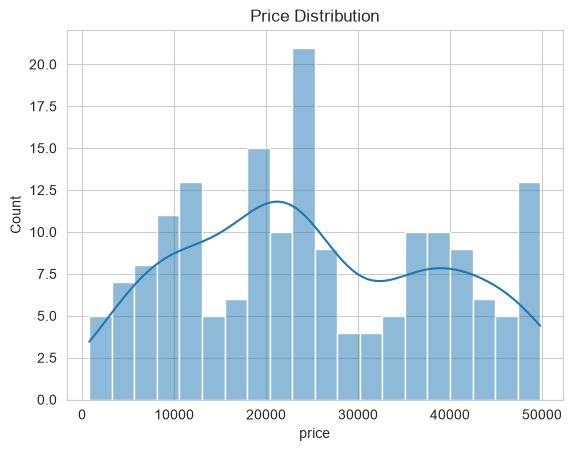

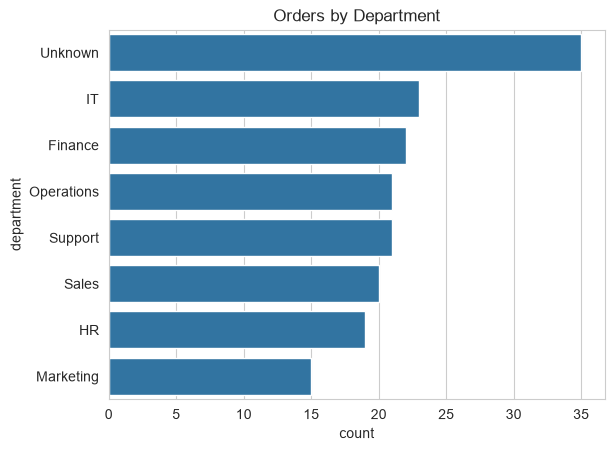

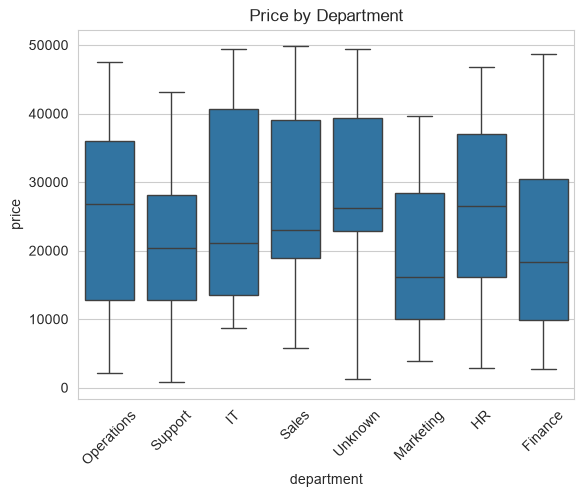

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.histplot(df_clean["price"], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

sns.countplot(data=df_clean, y="department", order=df_clean["department"].value_counts().index)
plt.title("Orders by Department")
plt.show()

sns.boxplot(data=df_clean, x="department", y="price")
plt.xticks(rotation=45)
plt.title("Price by Department")
plt.show()

# 1. Histogram — Price Distribution
What to look for: shape (skewed left/right, symmetric), where most values cluster, presence of outliers/spikes.
# 2. Count Plot — Orders by Department
What to look for: which category has the highest/lowest bar, how evenly spread the categories are.
# 3. Box Plot — Price by Department
What to look for: median line position, box height (spread/variability), whisker length, any dots above/below (outliers).
